# THREAT-SCOPE Bioinformatics Pipeline
Includes: data split, feature extraction (GC, length, k-mers), alignments, partial network and plots.

Tala Younes Mohamad Masnour


In [2]:
!pip install pandas scikit-learn biopython seaborn matplotlib

In [3]:
import pandas as pd
df = pd.read_csv('master.csv')
df.head(20)

,id,name,mode,label
0,1,cholera_1,water,danger
1,2,Ecoli_1,water,danger
2,3,Ecoli_2,water,danger
3,4,giardia_1,water,danger
4,5,hepatitusAvirus_1,water,danger
5,6,salmonella_1,water,danger
6,7,botulism,food,danger
7,8,campylobacter_1,food,danger
8,9,listeria_1,food,danger
9,10,salmonella_1,food,danger


In [4]:
from sklearn.model_selection import train_test_split
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)
train_df.to_csv('train.csv', index=False)
val_df.to_csv('validation.csv', index=False)
test_df.to_csv('test.csv', index=False)
print(len(train_df), len(val_df), len(test_df))

14 3 3


In [5]:
from Bio import SeqIO
from collections import Counter

files = [
 'cholera_1.fasta','Ecoli_1.fasta','Ecoli_2.fasta','giardia_1.fasta','hepatitusAvirus_1.fasta','salmonella_1.fasta',
 'botulism.fasta','campylobacter_1.fasta','listeria_1.fasta','salmonella_1.fasta',
 'pseudomonas_1.fasta','staphylococcus_1.fasta','streptococcus_1.fasta','tetanus_1.fasta',
 'ebola_1.fasta','influenza_1.fasta',
 'Bifidobacterium_longum_1.fasta','Lactobacillus_acidophilus_1.fasta','Lactococcus_lactis_1.fasta','Streptococcus_thermophilus_1.fasta'
]

def gc_content(seq):
    seq=str(seq)
    return (seq.count('G')+seq.count('C'))/len(seq)

def kmer_frequencies(seq,k=3):
    seq=str(seq)
    kmers=[seq[i:i+k] for i in range(len(seq)-k+1)]
    counts=Counter(kmers)
    total=sum(counts.values())
    for key in counts:
        counts[key]/=total
    return counts

data=[]

for file in files:
    for record in SeqIO.parse(file,'fasta'):
        seq=record.seq
        kmer=kmer_frequencies(seq,3)
        data.append([
            file,
            gc_content(seq),
            len(seq),
            kmer.get('AAA',0),
            kmer.get('ATG',0),
            kmer.get('CGT',0)
        ])

features_df=pd.DataFrame(data,columns=['file','gc_content','length','kmer_AAA','kmer_ATG','kmer_CGT'])
features_df.head(30)

,file,gc_content,length,kmer_AAA,kmer_ATG,kmer_CGT
0,cholera_1.fasta,0.477229,2948589,0.026574,0.016923,0.012661
1,cholera_1.fasta,0.469186,1140710,0.028197,0.017353,0.012212
2,cholera_1.fasta,0.412253,49113,0.034758,0.022072,0.010100
3,Ecoli_1.fasta,0.507907,4641652,0.023475,0.016434,0.015767
4,Ecoli_2.fasta,0.505370,5498578,0.023964,0.016699,0.015464
5,Ecoli_2.fasta,0.434059,3306,0.023910,0.016041,0.012409
6,Ecoli_2.fasta,0.475998,92721,0.030846,0.021258,0.012683
7,giardia_1.fasta,0.471451,1485438,0.016487,0.016372,0.011351
8,giardia_1.fasta,0.476051,1539535,0.016059,0.016634,0.011589
9,giardia_1.fasta,0.468689,1973847,0.015779,0.016386,0.011184


In [6]:

#Pairwise alignments
from Bio import SeqIO, pairwise2
from Bio.pairwise2 import format_alignment
from Bio.Align import MultipleSeqAlignment
from Bio.SeqRecord import SeqRecord
import networkx as nx
import matplotlib.pyplot as plt

# -------------------------
# Sample a few sequences
# -------------------------
sample_files = files[:5]  # first 5 DNA files
sample_seqs = []

for f in sample_files:
    for rec in SeqIO.parse(f, "fasta"):
        # take only first 1000 bases to prevent crashing
        sample_seqs.append(rec.seq[:1000])

print(f"Loaded {len(sample_seqs)} sequences for alignment/network demo")

print("\n=== Pairwise Alignment (first 2 sequences) ===")
alignment = pairwise2.align.globalxx(sample_seqs[0], sample_seqs[1])

# Show top 2 alignments
for a in alignment[:2]:
    print(format_alignment(*a))



/usr/local/lib/python3.12/dist-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


Loaded 43 sequences for alignment/network demo

=== Pairwise Alignment (first 2 sequences) ===
GTGT-TTGACACAACAGTTTATC-TCG----CTA-A-AATGGCC--GCC-TCTTCTGAAGCAGACCGCTAA-G-A---AGA--ACGCT--CT--TTAAC-A--A-T--AT----AAA-CCAATCAATCTGTGT--G-G--GC--ACTC--GTTG--AT-GATAATC-AAAA--AAGA-TT--TAT--C--A-AT--GAA-CTGAGTGACCATT--TGAG-TGAGCAATCATTCAGCACAGTCAAT-TCA-CTATCGAAA-GAT-AGTATCAGTATTCATTGAGCC----GAAGCGAA-AGCT-TCACAA-AA-CT-TTTA-A--T-TG---AA-G--AGT--TT-GATC-ATGG-CTCAG-ATTGAACGCTGGC-GGCAG--GCCTAA-CA-CATGC-A-AGTCG-AGC-G--GCAGCA-CAGAGGAACTTGTTCCT-TGG-GTGGCGA-GCGG-CGGACGGGTGAGTAATGCCT-GG-GAA-A-T-T-GCCCG--GT-A-G-AG-G-G--GGATAACCATTGG-AAAC-GATGGCTAA-TACCG-CATA-ACCT-C-GCAAGAGCA--AA--GC--AGGGGACCTTCGGG-C-CTTG-CGC-T-ACCGGA--T-ATGCCCAGGTGGGATT--AG-CTAGTTGG-T------GA-GGTAAGGGCTCACC-AAGGCGAC-GATCCCTAGCTGGTC--TGAGAGG--ATGA-TCAG-----CC-A-C-ACTG---GA-A-CTGA----G--ACACGGTCCAGACTCC-T-ACGGGAG--G-CAGCAGTGGGGA----AT-ATTGCAC-AATG-G--GCGCAAGCCTGAT--GC-AGCC-AT-G--C---CG-C--GTGTAT--G-AAGAAGGCCT-TCGG--GTT---GTAA-AG---TA-CTTTC-

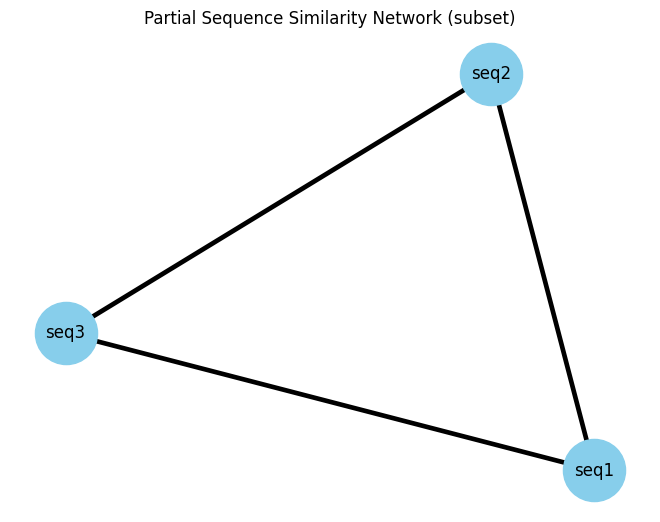

In [13]:
#Partial Multiple Sequence Alignment Network

# Take only first 3 sequences for network
msa_records = [SeqRecord(seq, id=f"seq{i+1}") for i, seq in enumerate(sample_seqs[:3])]
alignment = MultipleSeqAlignment(msa_records)

# Build similarity network (all edges, weighted)
G = nx.Graph()
for i in range(len(msa_records)):
    G.add_node(msa_records[i].id)

for i in range(len(msa_records)):
    for j in range(i+1, len(msa_records)):
        matches = sum(a==b for a,b in zip(msa_records[i].seq, msa_records[j].seq))
        percent_id = matches / min(len(msa_records[i].seq), len(msa_records[j].seq))
        G.add_edge(msa_records[i].id, msa_records[j].id, weight=percent_id)

# Draw network with proportional edge thickness
pos = nx.spring_layout(G)

# Scale edges: map similarity [0,1] -> thickness [1,10]
weights = [1 + 9*G[u][v]['weight'] for u,v in G.edges()]

nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=2000, width=weights)
plt.title("Partial Sequence Similarity Network (subset)")
plt.show()

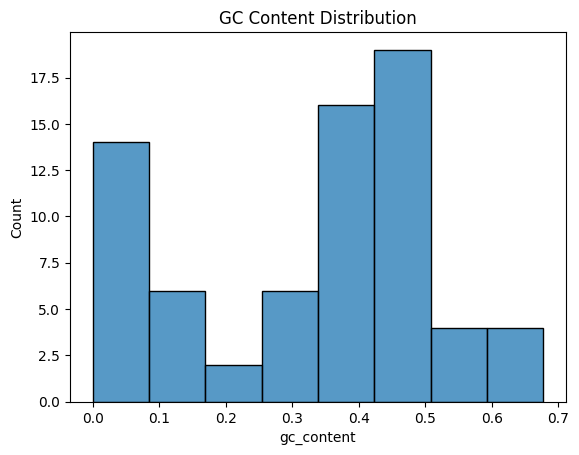

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(features_df['gc_content'])
plt.title('GC Content Distribution')
plt.show()

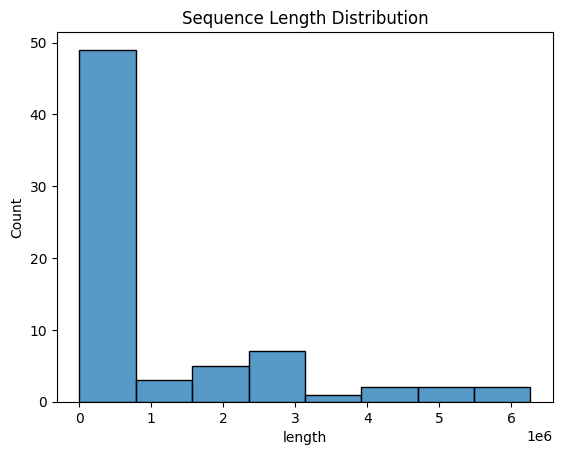

In [9]:
sns.histplot(features_df['length'])
plt.title('Sequence Length Distribution')
plt.show()

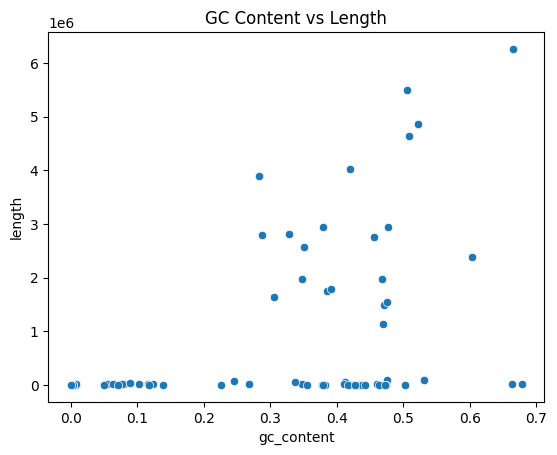

In [10]:
sns.scatterplot(x=features_df['gc_content'], y=features_df['length'])
plt.title('GC Content vs Length')
plt.show()

In [11]:
print('Total sequences:', len(features_df))

Total sequences: 71
